# Etapa 2 — Análise Exploratória de Dados (EDA)

**Objetivo:** Caracterizar a série temporal de vendas diárias de BEVERAGES: tendência, sazonalidade, distribuição, estacionariedade e eventos especiais.

**Entrada:** `data/processed/beverages_daily.csv`  
**Saídas:** Gráficos em `outputs/figures/` + resultados em `RESULTADOS.md`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'figure.titlesize': 12
})

PROCESSED_DIR = '../data/processed/'
FIGURES_DIR = '../outputs/figures/'

daily = pd.read_csv(PROCESSED_DIR + 'beverages_daily.csv', parse_dates=['date'])
daily = daily.set_index('date')
print(f'Série carregada: {len(daily)} observações')
print(f'Período: {daily.index.min().date()} a {daily.index.max().date()}')
daily.head()

Série carregada: 1684 observações
Período: 2013-01-01 a 2017-08-15


,sales,onpromotion,oil_price,is_national_holiday
date,,,,
2013-01-01,810.0,0,93.14,1
2013-01-02,72092.0,0,93.14,0
2013-01-03,52105.0,0,92.97,0
2013-01-04,54167.0,0,93.12,0
2013-01-05,77818.0,0,93.12,1


## 2.1 Série temporal diária

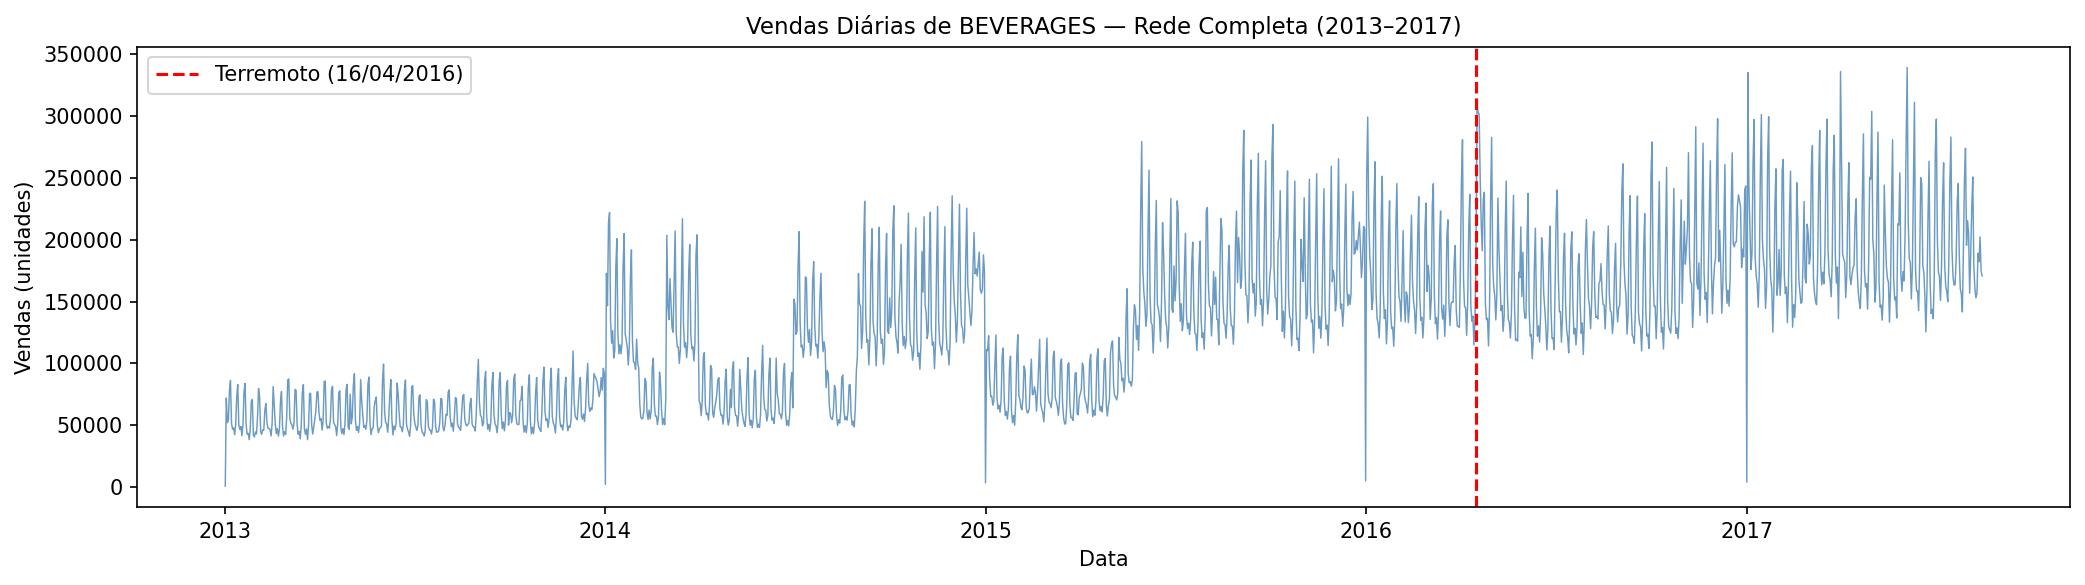

Salvo: 01_serie_diaria.png


In [2]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily.index, daily['sales'], color='steelblue', linewidth=0.7, alpha=0.8)
ax.axvline(pd.Timestamp('2016-04-16'), color='red', linestyle='--', linewidth=1.5, label='Terremoto (16/04/2016)')
ax.set_title('Vendas Diárias de BEVERAGES — Rede Completa (2013–2017)')
ax.set_xlabel('Data')
ax.set_ylabel('Vendas (unidades)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.savefig(FIGURES_DIR + '01_serie_diaria.png', bbox_inches='tight')
plt.show()
print('Salvo: 01_serie_diaria.png')

## 2.2 Série mensal (resampled)

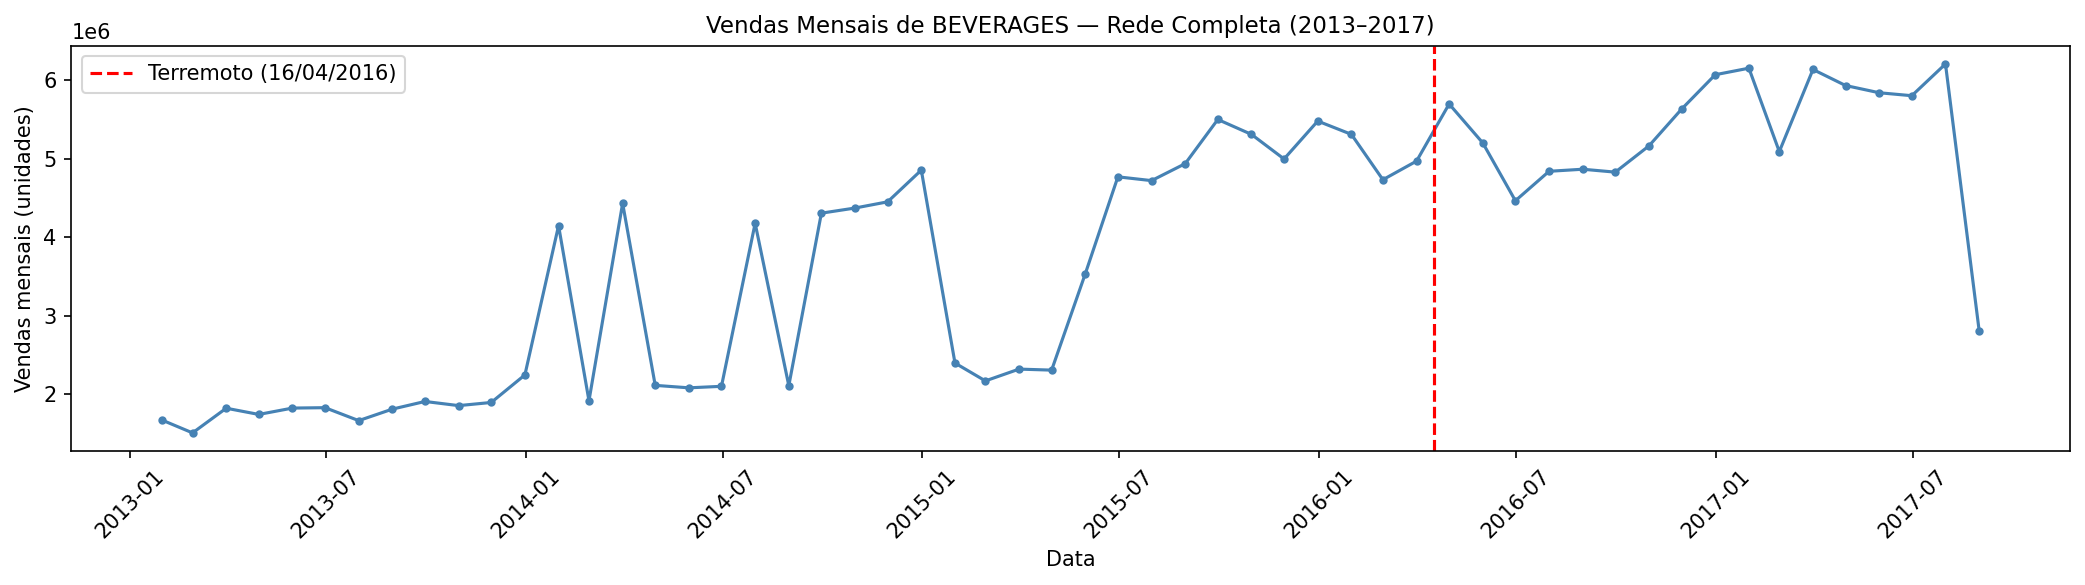

Salvo: 02_serie_mensal.png

Média diária 2013: 59829
Média diária 2016: 169172
Média diária 2017: 193624
Variação 2013→2017: 223.6%


In [3]:
monthly = daily['sales'].resample('ME').sum()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly.index, monthly.values, color='steelblue', marker='o', markersize=3, linewidth=1.5)
ax.axvline(pd.Timestamp('2016-04-16'), color='red', linestyle='--', linewidth=1.5, label='Terremoto (16/04/2016)')
ax.set_title('Vendas Mensais de BEVERAGES — Rede Completa (2013–2017)')
ax.set_xlabel('Data')
ax.set_ylabel('Vendas mensais (unidades)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR + '02_serie_mensal.png', bbox_inches='tight')
plt.show()
print('Salvo: 02_serie_mensal.png')

# Calcular variação tendência
vendas_2013 = daily['sales']['2013'].mean()
vendas_2016 = daily['sales']['2016'].mean()
vendas_2017 = daily['sales']['2017'].mean()
variacao_total = (vendas_2017 - vendas_2013) / vendas_2013 * 100
print(f'\nMédia diária 2013: {vendas_2013:.0f}')
print(f'Média diária 2016: {vendas_2016:.0f}')
print(f'Média diária 2017: {vendas_2017:.0f}')
print(f'Variação 2013→2017: {variacao_total:.1f}%')

## 2.3 Distribuição das vendas diárias

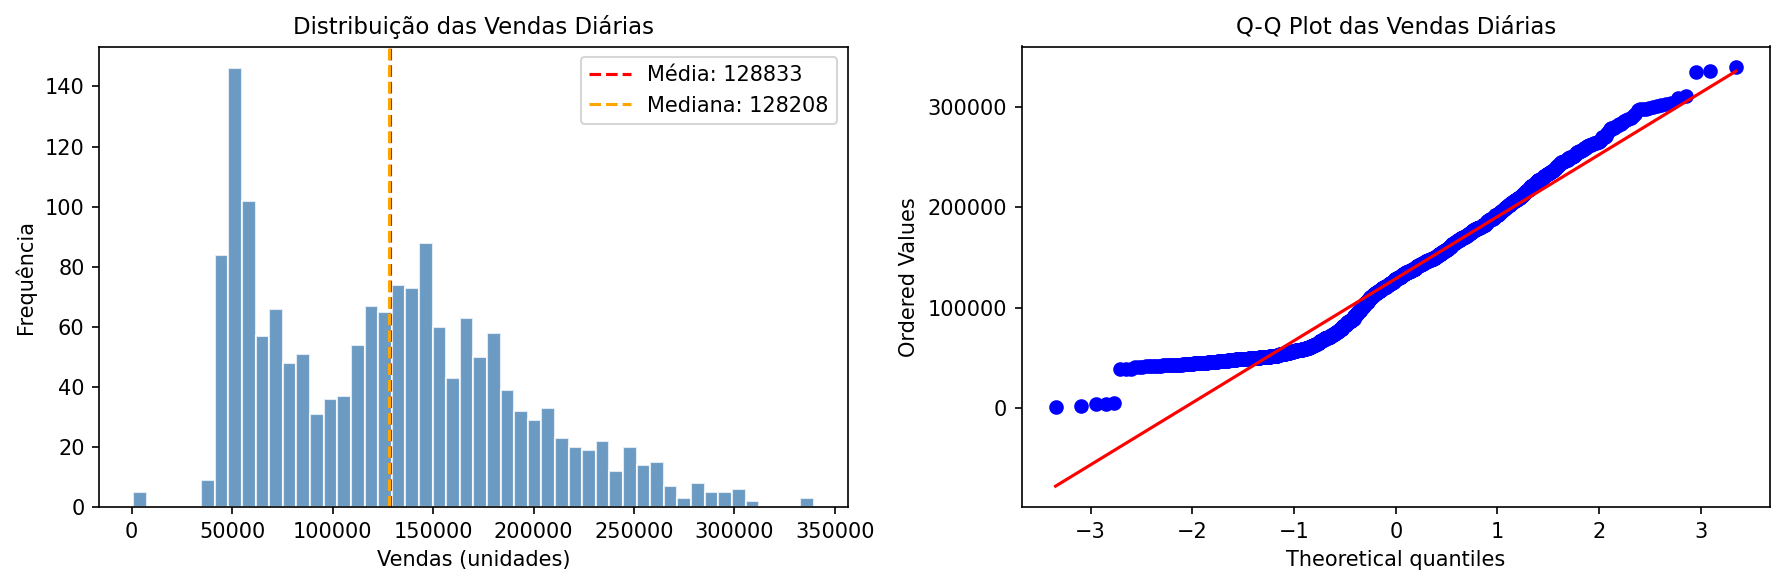

Salvo: 03_histograma_vendas.png
Assimetria (skewness): 0.496
Curtose (kurtosis): -0.378


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(daily['sales'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribuição das Vendas Diárias')
axes[0].set_xlabel('Vendas (unidades)')
axes[0].set_ylabel('Frequência')
axes[0].axvline(daily['sales'].mean(), color='red', linestyle='--', label=f'Média: {daily["sales"].mean():.0f}')
axes[0].axvline(daily['sales'].median(), color='orange', linestyle='--', label=f'Mediana: {daily["sales"].median():.0f}')
axes[0].legend()

from scipy import stats
stats.probplot(daily['sales'], dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot das Vendas Diárias')

plt.tight_layout()
plt.savefig(FIGURES_DIR + '03_histograma_vendas.png', bbox_inches='tight')
plt.show()
print('Salvo: 03_histograma_vendas.png')

from scipy.stats import skew, kurtosis
print(f'Assimetria (skewness): {skew(daily["sales"]):.3f}')
print(f'Curtose (kurtosis): {kurtosis(daily["sales"]):.3f}')

## 2.4 Boxplot por dia da semana e por mês

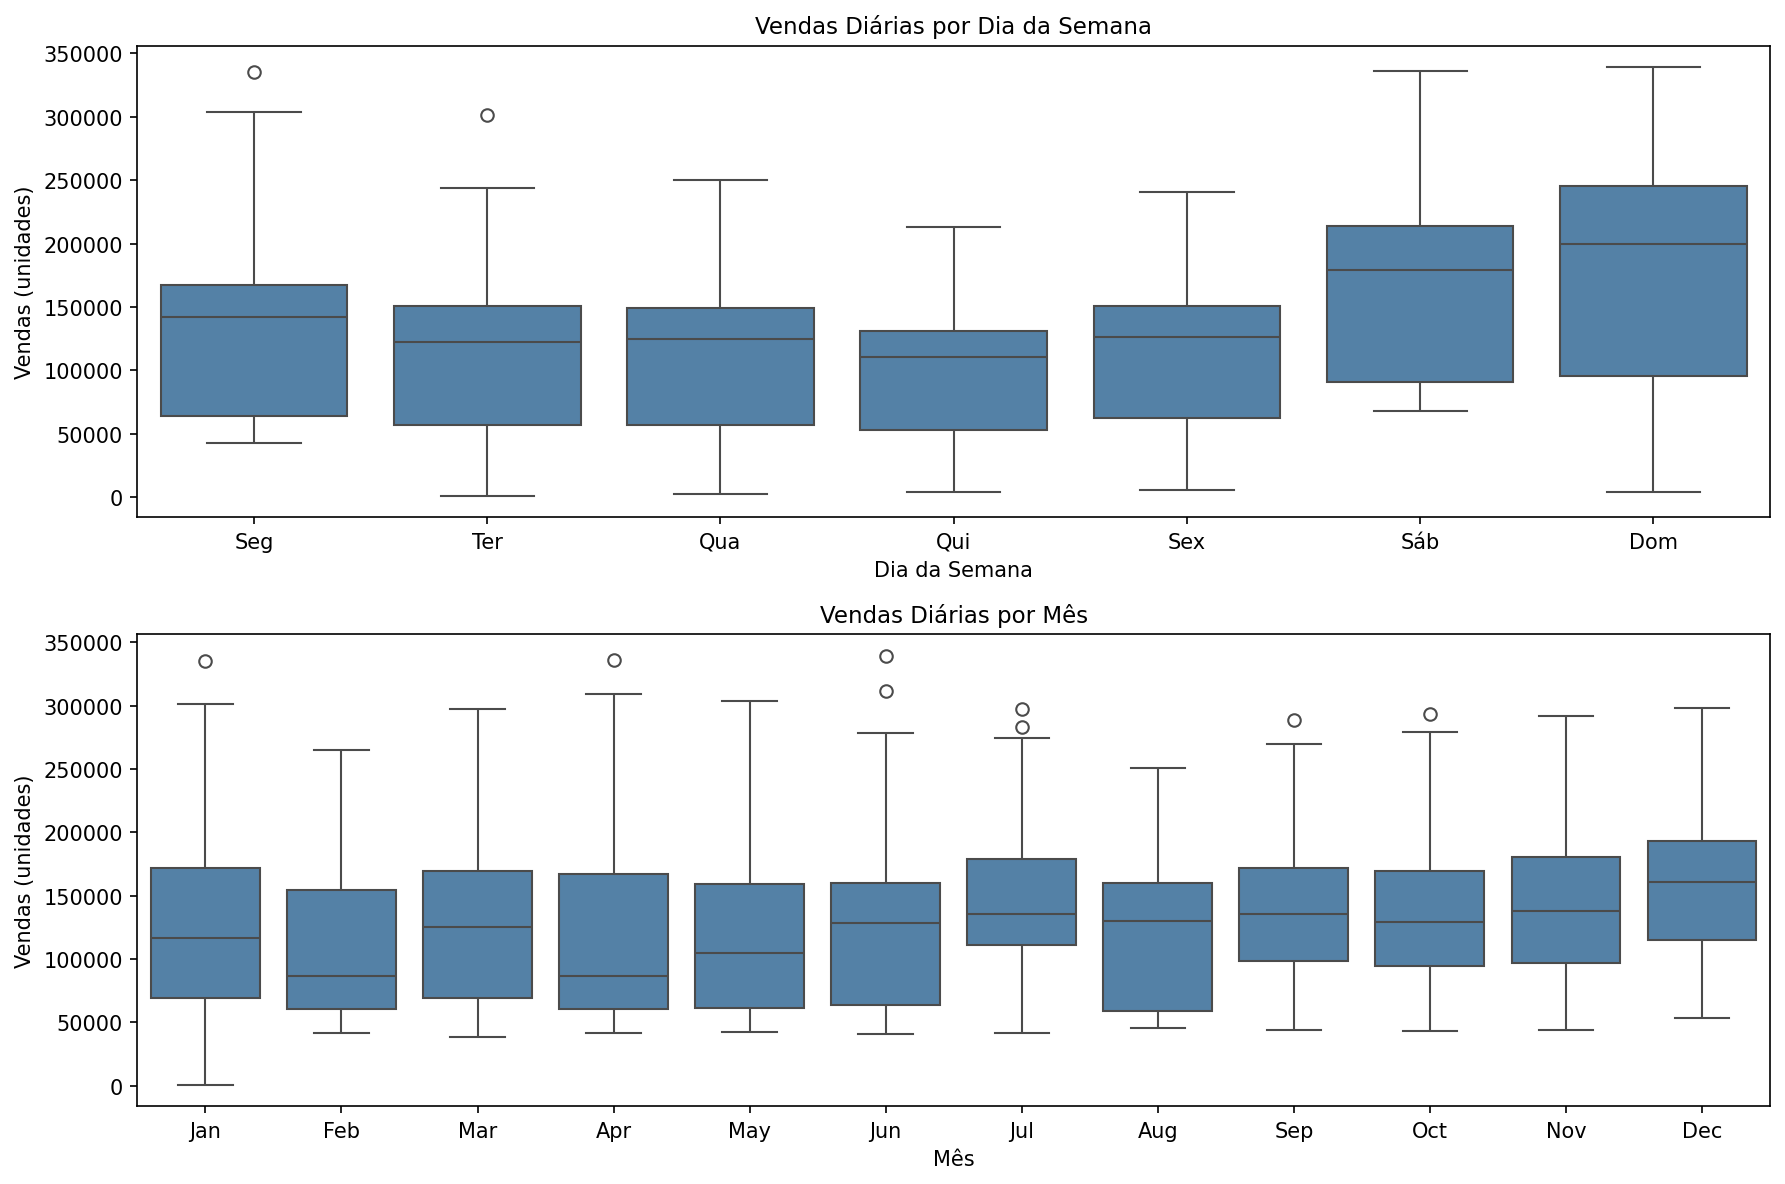

Salvo: 04_boxplot_sazonalidade.png

Média por dia da semana:
day_of_week
Monday       123882.0
Tuesday      111519.0
Wednesday    111890.0
Thursday      99489.0
Friday       115317.0
Saturday     161783.0
Sunday       177977.0
Name: sales, dtype: float64

Média por mês:
month
1     126913.0
2     109318.0
3     126927.0
4     118582.0
5     119198.0
6     126401.0
7     139363.0
8     118916.0
9     137811.0
10    134632.0
11    141398.0
12    155353.0
Name: sales, dtype: float64


In [5]:
daily_plot = daily.copy().reset_index()
daily_plot['day_of_week'] = daily_plot['date'].dt.day_name()
daily_plot['month'] = daily_plot['date'].dt.month
daily_plot['month_name'] = daily_plot['date'].dt.strftime('%b')

dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Boxplot por dia da semana
sns.boxplot(data=daily_plot, x='day_of_week', y='sales', order=dow_order, ax=axes[0], color='steelblue')
axes[0].set_title('Vendas Diárias por Dia da Semana')
axes[0].set_xlabel('Dia da Semana')
axes[0].set_ylabel('Vendas (unidades)')
axes[0].set_xticklabels(['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom'])

# Boxplot por mês
month_present = [m for m in month_order if m in daily_plot['month_name'].values]
sns.boxplot(data=daily_plot, x='month_name', y='sales', order=month_present, ax=axes[1], color='steelblue')
axes[1].set_title('Vendas Diárias por Mês')
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('Vendas (unidades)')

plt.tight_layout()
plt.savefig(FIGURES_DIR + '04_boxplot_sazonalidade.png', bbox_inches='tight')
plt.show()
print('Salvo: 04_boxplot_sazonalidade.png')

# Médias por dia da semana (para RESULTADOS.md)
dow_means = daily_plot.groupby('day_of_week')['sales'].mean().reindex(dow_order)
print('\nMédia por dia da semana:')
print(dow_means.round(0))

month_means = daily_plot.groupby('month')['sales'].mean()
print('\nMédia por mês:')
print(month_means.round(0))

## 2.5 Decomposição sazonal

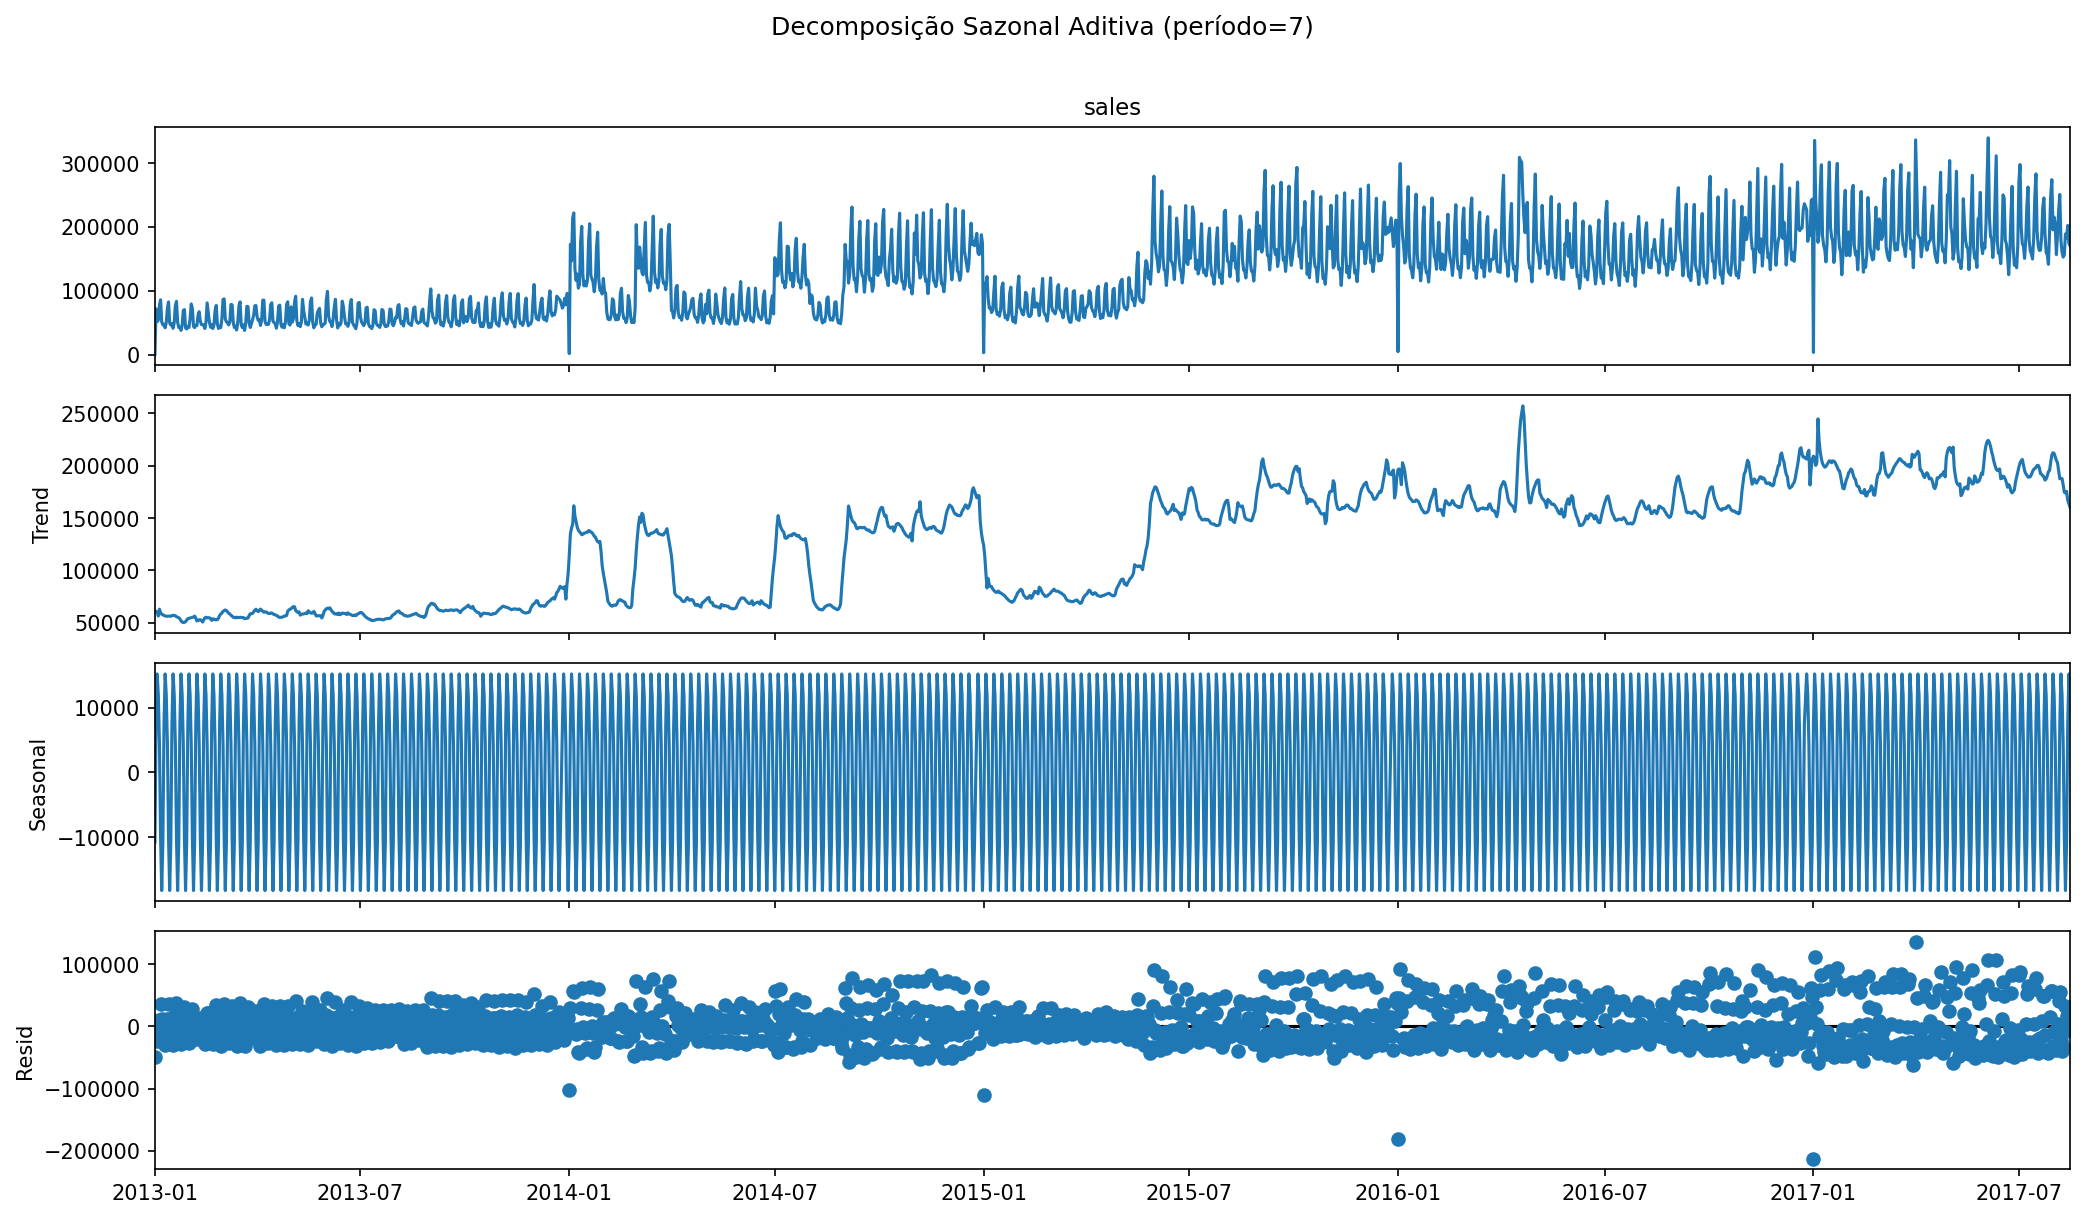

Salvo: 05_decomposicao_aditiva.png


In [6]:
# Testar aditiva e multiplicativa
series = daily['sales']

# Decomposição aditiva (period=7 — sazonal semanal)
decomp_add = seasonal_decompose(series, model='additive', period=7, extrapolate_trend='freq')

fig = decomp_add.plot()
fig.set_size_inches(14, 8)
fig.suptitle('Decomposição Sazonal Aditiva (período=7)', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR + '05_decomposicao_aditiva.png', bbox_inches='tight')
plt.show()
print('Salvo: 05_decomposicao_aditiva.png')

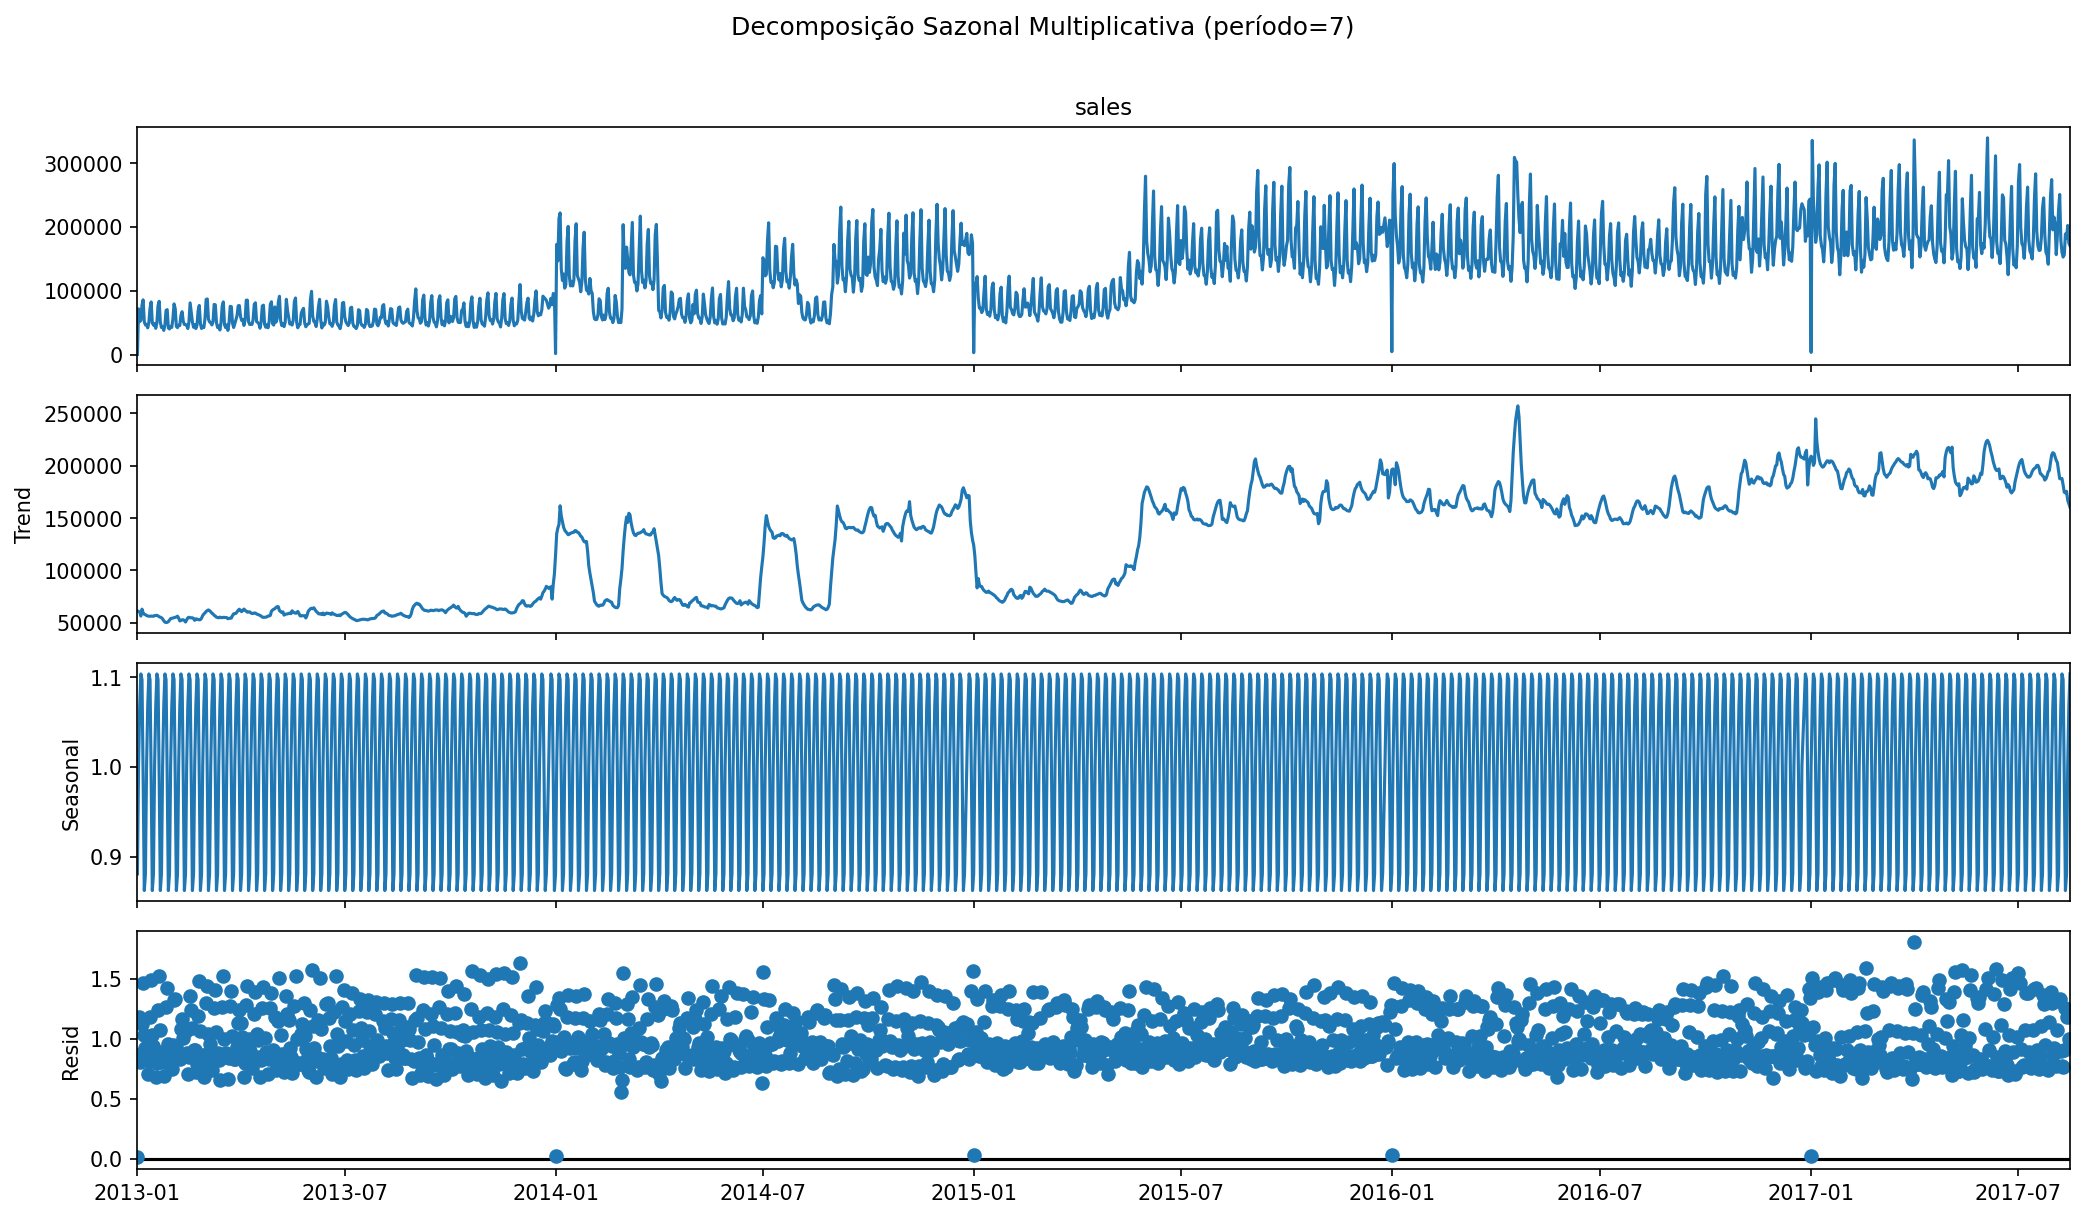

Salvo: 06_decomposicao_multiplicativa.png

CV dos resíduos — aditiva: -3198.2145
CV dos resíduos — multiplicativa: 0.2222

Correlação tendência-resíduo — aditiva: 0.0110
Correlação tendência-resíduo — multiplicativa: 0.0241


In [7]:
# Decomposição multiplicativa
decomp_mult = seasonal_decompose(series, model='multiplicative', period=7, extrapolate_trend='freq')

fig = decomp_mult.plot()
fig.set_size_inches(14, 8)
fig.suptitle('Decomposição Sazonal Multiplicativa (período=7)', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR + '06_decomposicao_multiplicativa.png', bbox_inches='tight')
plt.show()
print('Salvo: 06_decomposicao_multiplicativa.png')

# Comparar variância dos resíduos (critério de escolha)
resid_add_cv = decomp_add.resid.dropna().std() / decomp_add.resid.dropna().mean()
resid_mult_cv = decomp_mult.resid.dropna().std() / decomp_mult.resid.dropna().mean()
print(f'\nCV dos resíduos — aditiva: {resid_add_cv:.4f}')
print(f'CV dos resíduos — multiplicativa: {resid_mult_cv:.4f}')

# Verificar se variância do resíduo cresce com o nível (indicador de multiplicativa)
corr_level_resid_add = np.corrcoef(decomp_add.trend.dropna(), decomp_add.resid.dropna())[0, 1]
corr_level_resid_mult = np.corrcoef(decomp_mult.trend.dropna(), decomp_mult.resid.dropna())[0, 1]
print(f'\nCorrelação tendência-resíduo — aditiva: {corr_level_resid_add:.4f}')
print(f'Correlação tendência-resíduo — multiplicativa: {corr_level_resid_mult:.4f}')

## 2.6 Teste ADF de estacionariedade

In [8]:
def run_adf(series, label):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'=== ADF — {label} ===')
    print(f'  Estatística t: {result[0]:.4f}')
    print(f'  p-valor: {result[1]:.4f}')
    print(f'  Lags usados: {result[2]}')
    print(f'  Nobs: {result[3]}')
    print(f'  Valores críticos:')
    for k, v in result[4].items():
        print(f'    {k}: {v:.4f}')
    if result[1] < 0.05:
        print(f'  → Conclusão: ESTACIONÁRIA (p < 0.05)')
    else:
        print(f'  → Conclusão: NÃO ESTACIONÁRIA (p ≥ 0.05)')
    return result

adf_original = run_adf(daily['sales'], 'Série Original')
print()
adf_diff1 = run_adf(daily['sales'].diff(), 'Primeira Diferença')

=== ADF — Série Original ===
  Estatística t: -2.5291
  p-valor: 0.1085
  Lags usados: 22
  Nobs: 1661
  Valores críticos:
    1%: -3.4343
    5%: -2.8633
    10%: -2.5677
  → Conclusão: NÃO ESTACIONÁRIA (p ≥ 0.05)

=== ADF — Primeira Diferença ===
  Estatística t: -9.9637
  p-valor: 0.0000
  Lags usados: 25
  Nobs: 1657
  Valores críticos:
    1%: -3.4343
    5%: -2.8633
    10%: -2.5677
  → Conclusão: ESTACIONÁRIA (p < 0.05)


## 2.7 Impacto do terremoto de abril/2016

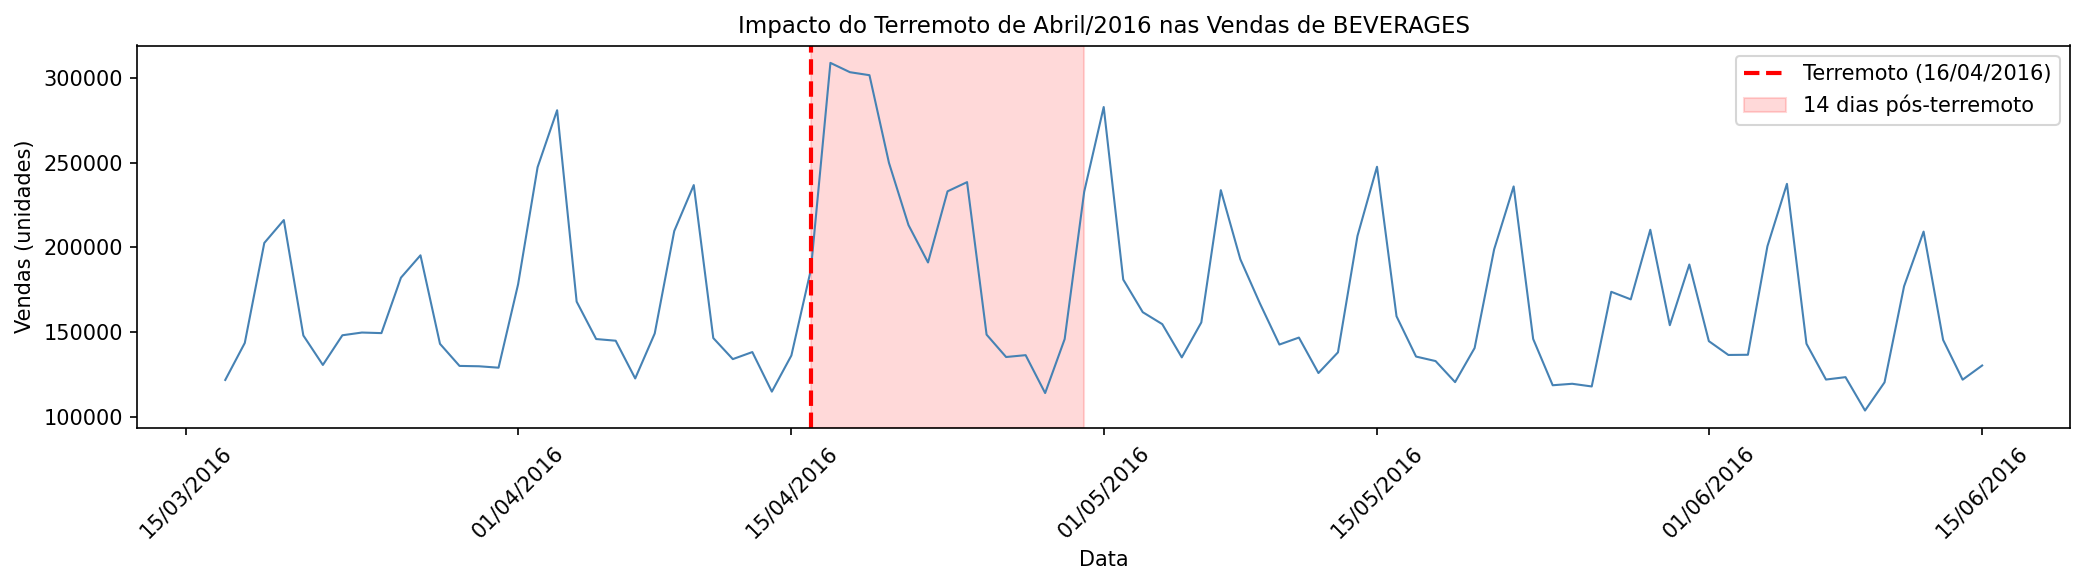

Salvo: 07_impacto_terremoto.png

Média 30 dias antes: 162519
Média 14 dias depois: 209328
Variação: 28.8%


In [9]:
# Janela de análise: 30 dias antes e 60 dias depois do terremoto
earthquake_date = pd.Timestamp('2016-04-16')
window_start = earthquake_date - pd.Timedelta(days=30)
window_end = earthquake_date + pd.Timedelta(days=60)

earthquake_window = daily['sales'][window_start:window_end]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(earthquake_window.index, earthquake_window.values, color='steelblue', linewidth=1)
ax.axvline(earthquake_date, color='red', linestyle='--', linewidth=2, label='Terremoto (16/04/2016)')
ax.axvspan(earthquake_date, earthquake_date + pd.Timedelta(days=14),
           alpha=0.15, color='red', label='14 dias pós-terremoto')
ax.set_title('Impacto do Terremoto de Abril/2016 nas Vendas de BEVERAGES')
ax.set_xlabel('Data')
ax.set_ylabel('Vendas (unidades)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR + '07_impacto_terremoto.png', bbox_inches='tight')
plt.show()
print('Salvo: 07_impacto_terremoto.png')

# Quantificar o impacto
media_30dias_antes = daily['sales'][window_start:earthquake_date - pd.Timedelta(days=1)].mean()
media_14dias_depois = daily['sales'][earthquake_date:earthquake_date + pd.Timedelta(days=14)].mean()
variacao_pct = (media_14dias_depois - media_30dias_antes) / media_30dias_antes * 100
print(f'\nMédia 30 dias antes: {media_30dias_antes:.0f}')
print(f'Média 14 dias depois: {media_14dias_depois:.0f}')
print(f'Variação: {variacao_pct:.1f}%')

## 2.8 Resumo dos achados da EDA

> **CHECKPOINT OBRIGATÓRIO** — Antes de avançar para feature engineering, resumir os achados e apresentar ao aluno para confirmação.

In [1]:
print('=' * 60)
print('RESUMO DOS ACHADOS DA EDA — BEVERAGES')
print('=' * 60)
print()

# Tendência
vendas_2013 = daily['sales']['2013'].mean()
vendas_2017 = daily['sales']['2017'].mean()
variacao = (vendas_2017 - vendas_2013) / vendas_2013 * 100
print(f'TENDÊNCIA:')
print(f'  Média diária 2013: {vendas_2013:.0f} unidades')
print(f'  Média diária 2017: {vendas_2017:.0f} unidades')
print(f'  Variação 2013→2017: {variacao:.1f}%')
print()

# Sazonalidade semanal
daily_plot2 = daily.reset_index()
daily_plot2['dow'] = daily_plot2['date'].dt.dayofweek
dow_means = daily_plot2.groupby('dow')['sales'].mean()
peak_dow = dow_means.idxmax()
low_dow = dow_means.idxmin()
dow_names = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']
print(f'SAZONALIDADE SEMANAL:')
print(f'  Pico: {dow_names[peak_dow]} (média: {dow_means[peak_dow]:.0f})')
print(f'  Vale: {dow_names[low_dow]} (média: {dow_means[low_dow]:.0f})')
amplitude = (dow_means[peak_dow] - dow_means[low_dow]) / dow_means[low_dow] * 100
print(f'  Amplitude pico/vale: {amplitude:.1f}%')
print()

# ADF
print(f'ESTACIONARIEDADE:')
print(f'  ADF série original: p={adf_original[1]:.4f} → {"NÃO ESTACIONÁRIA" if adf_original[1] >= 0.05 else "ESTACIONÁRIA"}')
print(f'  ADF 1ª diferença: p={adf_diff1[1]:.4f} → {"NÃO ESTACIONÁRIA" if adf_diff1[1] >= 0.05 else "ESTACIONÁRIA"}')
print()

# Terremoto
print(f'TERREMOTO DE ABRIL/2016:')
print(f'  Média 30 dias antes: {media_30dias_antes:.0f}')
print(f'  Média 14 dias depois: {media_14dias_depois:.0f}')
print(f'  Variação: {variacao_pct:.1f}%')
print()

print('OUTLIERS: verificar plot da série diária — pico máximo e mínimo absoluto.')
print(f'  Máximo: {daily["sales"].max():.0f} em {daily["sales"].idxmax().date()}')
print(f'  Mínimo: {daily["sales"].min():.0f} em {daily["sales"].idxmin().date()}')
print()

RESUMO DOS ACHADOS DA EDA — BEVERAGES



NameError: name 'daily' is not defined